# Demonstration of TE Estimation on Synthetic Data 

## Data Generation

We use the same data generatation scheme from the following paper:

>Shorten DP, Spinney RE, Lizier JT (2021) Estimating Transfer Entropy in Continuous Time Between Neural Spike Trains or Other Event-Based Data. PLoS Comput Biol 17(4): e1008054. https://doi.org/10.1371/journal.pcbi.1008054 

In this scheme, the true transfer entropy rate is given in the paper as **0.5076±0.001 nats per second**.


In [1]:
import sys
import os
# Adds the project root to the path
sys.path.append(os.path.abspath(".."))

d:\Miniconda-ENV\ifl-tpp-new\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Plotting results...
Plotting results...
Plot saved as avg_firing_rate_from_last_source.png
Plotting results for firing_rate_over_time.png with time_step=10.0s...
Plot saved as firing_rate_over_time.png


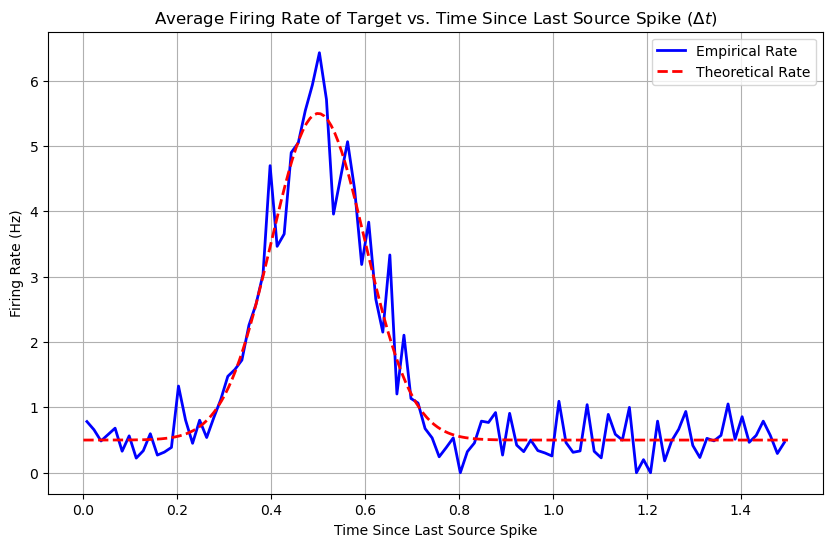

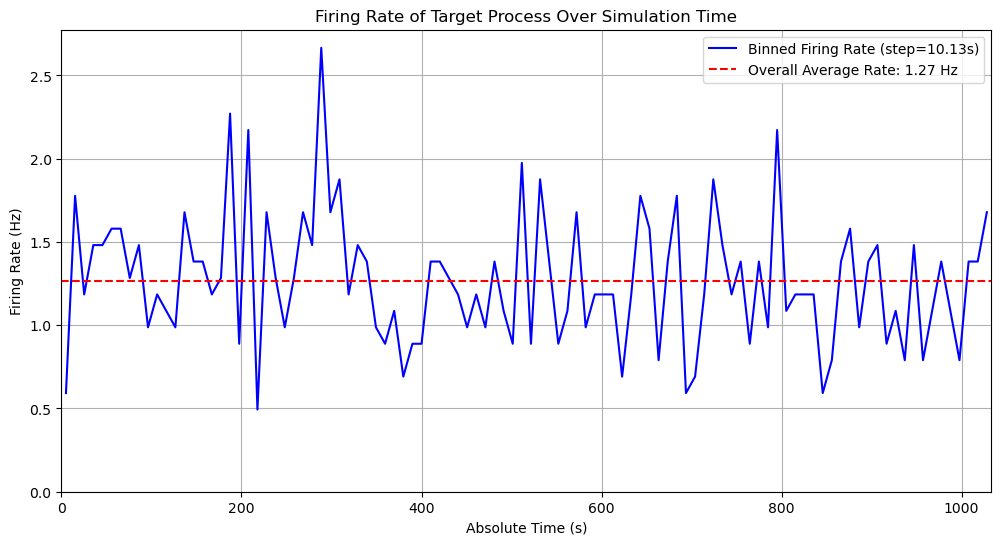

In [2]:
from src.CoTETE_example_test import generate_spike_trains_CoTETE, plot_average_firing_rate, plot_firing_rate_over_time

# Set random seed and number of source events
seed=51
num_source_events = int(1e+3)
os.makedirs("results", exist_ok=True)

# Generate event times for source and target events
source_events, target_events, candidates, accepted = generate_spike_trains_CoTETE(NUM_Y_EVENTS=num_source_events,seed=seed+1)

plot_average_firing_rate(candidates, accepted, RATE_X_MAX=10) # Plot average firing rate for candidates and accepted events with a maximum rate of 10 Hz
plot_firing_rate_over_time(target_events, time_step=10.0) # Plot firing rate over time for target events for the first 10 seconds of the simulation

## Hyperparameter Optimization

We optimize the hyperparameters on the validation set after splitting the data. The complete optimization code is in `CoTETE_example_opt_yy-yyx.py`.

First we set the hyperparameter ranges in the `create_objective` function.

In [3]:
import numpy as np
from src.entropy_tpp import TE_estimation_tpp
import torch
from copy import deepcopy
import optuna

def create_objective(arrival_times_target_list, arrival_times_source_list,
                     time_series_length, device, seed):
    """
    This outer function creates and returns the actual objective function.
    It takes the data as an argument.
    """
    
    def objective(trial):
        # 1. Suggest hyperparameters

        n_layers = trial.suggest_int("n_layers", 1, 2) # From 1 to 5 hidden layers
        hidden_sizes = []
        for i in range(n_layers):
            # Suggest the size for each hidden layer dynamically
            layer_size = 2** trial.suggest_int(f"hidden_size_l{i}", 2, 6)
            hidden_sizes.append(layer_size)

        configs = {
            "model_config_yy": {
                "model_name": "LogNormMix",  # Name of the model to use, ["LogNormMix", "ExponentialMix","GompertzMix"]
                "context_size": 2** trial.suggest_int("context_size", 1, 4),  # From 2^0 to 2^7, i.e., 1 to 128, Size of the RNN hidden vector
                "num_mix_components": 2** trial.suggest_int("num_mix_components", 1, 5),  # 32 Number of components for a mixture model
                "hidden_sizes": hidden_sizes,       # 16 Hidden sizes of the MLP for the inter-event time distribution
                "context_extractor": trial.suggest_categorical("context_extractor", ["gru", "lstm"]), # Type of RNN to use for context extraction, ["gru", "lstm", "mlp"]
                "activation_func": trial.suggest_categorical("activation_func", ["Tanh", "ReLU", "GELU"]),
            },
            "train_config_yy": {
                "L2_weight": trial.suggest_float("L2_weight", 1e-10, 1e-3, log=True),          # L2 regularization parameter
                "L_entropy_weight": trial.suggest_float("L_entropy_weight", 1e-10, 1e-3, log=True),      # Weight for the entropy regularization term
                "L_sep_weight": trial.suggest_float("L_sep_weight", 1e-10, 1e-3, log=True),               # Weight for the separation regularization term
                "L_scale_weight": trial.suggest_float("L_scale_weight", 1e-10, 1e-3, log=True),             # Weight for the scale regularization term
                "learning_rate": trial.suggest_float("learning_rate", 5e-4, 1e-2, log=True),           # Learning rate for Adam optimizer
                "max_epochs": 500,              # For how many epochs to train
                "display_step": 5,               # Display training statistics after every display_step
                "patience": 20,                  # After how many consecutive epochs without improvement of val loss to stop training
            },
            "data_prep_config":{
                "batch_size": 128,          # Number of sequences in a batch
                "shuffle": False,                 # Whether to shuffle the time series before splitting into train/val/test
                "total_time": time_series_length,              # in second, Total time of the sequences
                "verbose": False
            },
            "device": device,
            "verbose": False,  # Whether to print the training statistics
            "plot_histograms": False,  # Whether to plot the conditional histograms
            "history_length": 8,             # in number of bins, Length of the history to use for the model
            "plot_pp": False,  # Whether to plot the PP plots
        }
        configs["model_config_yyx"]=configs["model_config_yy"]
        configs["train_config_yyx"]=configs["train_config_yy"]
        # 2. Run your TE estimation with the suggested hyperparameters
        # You'll need to adapt this part to call the relevant functions in your entropy_tpp.py
        # For instance, if you have a main function that takes these as arguments:
        # te_train, te_val, te_test = calculate_te(param1, param2)
        
        log_losses_yy = []
        log_losses_yyx = []
        TEs = []
        for i in range(len(arrival_times_target_list)):
            arrival_times_target = arrival_times_target_list[i]
            arrival_times_source = arrival_times_source_list[i]

            print("Number of events in target process:", len(arrival_times_target))
            print("Number of events in source process:", len(arrival_times_source))

            len_target = len(arrival_times_target)
            try:
                (TE_hazard, H_yy_hazard, H_yyx_hazard), (log_loss_yy, log_loss_yyx)= TE_estimation_tpp(
                    event_time=[arrival_times_target, arrival_times_source],
                    configs=deepcopy(configs),
                    seed=seed*(i+1),
                    trial=trial
                )
            except optuna.TrialPruned:
                # If the inner training loop raises TrialPruned, catch it and re-raise
                # so Optuna knows to stop this trial.
                raise optuna.TrialPruned()
            
            log_losses_yy.append(log_loss_yy)
            log_losses_yyx.append(log_loss_yyx)
            TEs.append(TE_hazard)
            if  TE_hazard == float('nan'):
                print(f"Error during TE estimation for run {i+1}. Skipping this run.\n")
                return None, None
            
        
            print(f'Log loss for model yy: {log_loss_yy:.5f}')
            print(f'Log loss for model yyx: {log_loss_yyx:.5f}')
            print(f'Estimated TE for run {i+1}: {TE_hazard:.5f} nats/sec')

            trial.set_user_attr(f"te_sec_run_{i}", TE_hazard)
            trial.set_user_attr(f"log_loss_yy_run_{i}", log_loss_yy)
            trial.set_user_attr(f"log_loss_yyx_run_{i}", log_loss_yyx)
            
        trial.set_user_attr(f"log_loss_sum", np.sum(log_losses_yyx) + np.sum(log_losses_yy))
        trial.set_user_attr(f"te_sec_mean", np.mean(TEs))
        # 3. Return the metric to optimize
        return  np.mean(log_losses_yyx)+ np.mean(log_losses_yy)

    return objective

Here we only demostrate using one pair of source and target, though the framwork is compactable for optimizing on multiple pairs at the same time.

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

min_time_length = float('inf')
source_events_list = []
target_events_list = []
source_events_list.append(torch.tensor(source_events, dtype=torch.float))
target_events_list.append(torch.tensor(target_events, dtype=torch.float))
min_time_length = min(min_time_length, source_events[-1], target_events[-1]) # in seconds


Using device: cuda


In [5]:
 # min_resource=10: Don't prune before epoch 10
# reduction_factor=3: Standard Hyperband setting
pruner = optuna.pruners.HyperbandPruner(min_resource=10, max_resource=500, reduction_factor=3)

objective_t = create_objective(source_events_list, target_events_list,
                    min_time_length, device, seed)

# Assuming 'objective' function is defined as above
# ,load_if_exists=True to continue from an existing study
study = optuna.create_study(directions=["minimize"], storage="sqlite:///demo.sqlite3"
                            ,load_if_exists=True, study_name=f"CoTETE_yy+yyx_{seed:02d}_{num_source_events:.0e}",
                            pruner=pruner) # Set direction to 'maximize' for TE,  

study.optimize(objective_t, n_trials=5) # n_trials=None means run for unlimited trials

print("Best trial:")
print(f"  Value: {study.best_value}")
print(f"  Params: {study.best_params}")

# Display an interactive plot in the next cell
optuna.visualization.plot_optimization_history(study)

[I 2026-03-04 10:54:50,026] Using an existing study with name 'CoTETE_yy+yyx_51_1e+03' instead of creating a new one.


Number of events in target process: 1000
Number of events in source process: 1309


[I 2026-03-04 10:55:03,643] Trial 5 pruned. 


Number of events in target process: 1000
Number of events in source process: 1309


[I 2026-03-04 10:55:09,595] Trial 6 pruned. 


...

[I 2026-03-04 10:55:13,131] Trial 7 pruned. 


Number of events in target process: 1000
Number of events in source process: 1309


[I 2026-03-04 10:55:15,359] Trial 8 pruned. 


Number of events in target process: 1000
Number of events in source process: 1309


AssertionError: Should not reach.

## Multiple Runs for TE Estimation

Using the optimized hyperparameters, we run multiple times for the estimation. This part of the code is from `CoTETE_example_test.py`. 

The single run TE estimation is implemented in `entropy_tpp.py`.

In [ ]:
from src.entropy_tpp import TE_estimation_tpp, run_multiple_estimation
from src.entropy_tpp import save_dict_indented

In [ ]:
import time
from copy import deepcopy

# Set random seeds for reproducibility
torch.manual_seed(seed)
np.random.seed(seed)

time_series_length = min(source_events[-1], target_events[-1])  # in seconds

configs = {
        "model_config_yy": {
        "model_name": "LogNormMix_yy",
        "context_size": 16,
        "num_mix_components": 8,
        "hidden_sizes": [4, 16],
        "context_extractor": "lstm",
        "activation_func": "GELU"
    },
    "model_config_yyx": {
        "model_name": "LogNormMix_yyx",
        "context_size": 8,
        "num_mix_components": 32,
        "hidden_sizes": [8, 32],
        "context_extractor": "gru",
        "activation_func": "Tanh"
    },
    "train_config_yy": {
        "L2_weight": 3.8379954060256066e-08,
        "L_entropy_weight": 0.00022756667123420592,
        "L_sep_weight": 2.891600870711327e-10,
        "L_scale_weight": 1.8621741962089573e-05,
        "learning_rate": 0.0024284476869901616,
        "max_epochs": 500,
        "display_step": 5,
        "patience": 20
    },
    "train_config_yyx": {
        "L2_weight": 0.00015034955189675413,
        "L_entropy_weight": 0.0002915120808357504,
        "L_sep_weight": 6.238313212626435e-06,
        "L_scale_weight": 4.033731713458755e-08,
        "learning_rate": 0.007882822631563417,
        "max_epochs": 500,
        "display_step": 5,
        "patience": 20
    },
    "data_prep_config":{
        "batch_size": 128,          # Number of sequences in a batch
        "shuffle": False,                 # Whether to shuffle the time series before splitting into train/val/test
        "total_time": time_series_length,              # in second, Total time of the sequences
        "verbose": False
    },
    "device": device,
    "verbose": False,  # Whether to print the training statistics
    "plot_histograms": False,  # Whether to plot the conditional histograms
    "plot_pp": False,            # Whether to plot the probability - probability plots
    "history_length": 256,             # in number of bins, Length of the history to use for the model
}

# Save the config for reference
save_dict_indented(configs, f"./results/config_{seed}.txt")

Indented configuration successfully saved to ./results/config_51.txt


Now we run the estimation. The result is saved in `./results/multiple_runs_results.csv`.

In [ ]:
config_plot = deepcopy(configs)
config_plot["plot_pp"] = True
start_time = time.time()
(TE_test, H_yy_test, H_yyx_test), (log_loss_yy, log_loss_yyx) = TE_estimation_tpp(
        event_time=[torch.tensor(target_events,dtype=torch.float), torch.tensor(source_events,dtype=torch.float)], 
        configs=config_plot, 
        seed=seed
)
end_time = time.time()
duration = end_time - start_time
print(f"\n--- TE Estimation Completed in {duration/60:.2f} minutes ---")
print(f"Estimated Transfer Entropy (nats per second): {TE_test}")
print(f"Estimated h_hazard(Y_t+1|Y_t) (nats per second): {H_yy_test}")
print(f"Estimated h_hazard(Y_t+1|Y_t,X_t) (nats per second): {H_yyx_test}")
print(f"Log Loss pdf (Y_t+1|Y_t): {log_loss_yy}")
print(f"Log Loss pdf (Y_t+1|Y_t,X_t): {log_loss_yyx}")

run_multiple_estimation(
    target_events=torch.tensor(target_events, dtype=torch.float),
    source_events=torch.tensor(source_events, dtype=torch.float),
    configs=configs,
    n_runs=10,
    seed=seed
)

Plotting P-P plot...
P-P plot saved to ./results/pp_plot/pp_plot_LogNormMix_yyx_51.png
Plotting P-P plot...
P-P plot saved to ./results/pp_plot/pp_plot_LogNormMix_yy_51.png
[Test] Transfer Entropy (nats/event):
 - ln_hazard_yy_test: -0.21374
 - ln_hazard_yyx_test: -0.20551
 - TE_test:  -0.00823

[Training] Transfer Entropy (nats/event):
 - ln_hazard_yy_train: -0.24502
 - ln_hazard_yyx_train: -0.29665
 - TE_train:  0.05163

[Validation] Transfer Entropy (nats/event):
 - ln_hazard_yy_val: -0.29732
 - ln_hazard_yyx_val: -0.29846
 - TE_val:  0.00114


--- TE Estimation Completed in 0.08 minutes ---
Estimated Transfer Entropy (nats per second): -0.010422672146266505
Estimated h_hazard(Y_t+1|Y_t) (nats per second): -0.2706325096879516
Estimated h_hazard(Y_t+1|Y_t,X_t) (nats per second): -0.2602098375416851
Log Loss pdf (Y_t+1|Y_t): 0.8932708820123323
Log Loss pdf (Y_t+1|Y_t,X_t): 0.9089417382684678
--- Starting 10 Multiple Runs Estimation ---


  0%|          | 0/10 [00:00<?, ?it/s]


--- Run 1/10 ---


  0%|          | 0/10 [00:02<?, ?it/s]


KeyboardInterrupt: 

The estimated TE results are plotted and saved in `./results/TE_sec_multiple_runs.png` after the runs automatically.

![TE_multiple_runs](./results/TE_sec_multiple_runs.png)